In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles, make_s_curve, make_swiss_roll

from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Dataset 1 

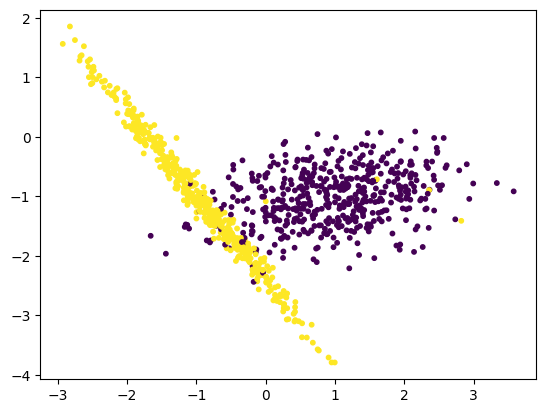

In [2]:
X1, y1 = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=10)
plt.scatter(X1[:, 0], X1[:, 1], s=10, c=y1);

In [3]:
X1.shape, y1.shape

((1000, 2), (1000,))

In [4]:
y_pr = KMeans(n_clusters=2,init='random', random_state=0).fit_predict(X1)

Text(0.5, 1.0, 'KMeans')

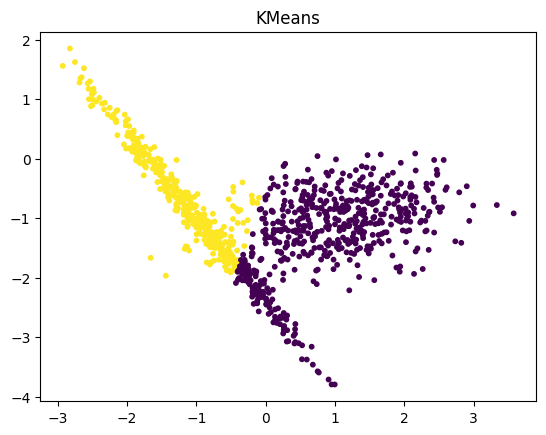

In [5]:
plt.scatter(X1[:, 0], X1[:, 1], s=10, c=y_pr)
plt.title('KMeans')

Text(0.5, 1.0, 'Agglomerative')

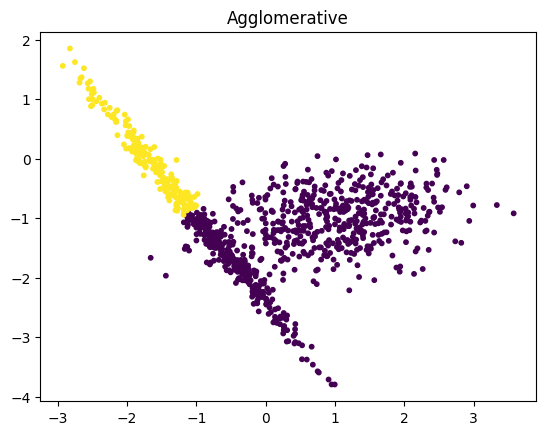

In [6]:
agg = AgglomerativeClustering(n_clusters=2)
y_pr = agg.fit_predict(X1)
plt.scatter(X1[:,0], X1[:,1], s = 10, c = y_pr)
plt.title('Agglomerative')

In [7]:
# import random
# l = [random.uniform(0,6) for _ in range(10000)]
# st = 0
# j = None
# for i in l:
#     dbscan = DBSCAN(eps = i)
#     y_pr = dbscan.fit_predict(X1)
#     if len(set(y_pr))==2:
#         sc = silhouette_score(X1, y_pr)
#         if sc > st:
#             st = sc
#             j = i
# print(f'silhouette score: {st}')
# print(f'epsilion: {j}')


In [8]:
def evaluate(X, clusters = 2, s = 30):
    y1=KMeans(n_clusters=clusters).fit_predict(X)
    y2=GaussianMixture(n_components=clusters).fit_predict(X)
    y3=AgglomerativeClustering(n_clusters=clusters).fit_predict(X)
    y4=AgglomerativeClustering(n_clusters=clusters, linkage = 'single').fit_predict(X)
    y5=AgglomerativeClustering(n_clusters=clusters, linkage = 'average').fit_predict(X)
    y6=AgglomerativeClustering(n_clusters=clusters, linkage = 'complete').fit_predict(X)
    
    fig, ax = plt.subplots(2,3,figsize = (16,5))
    ax[0,0].scatter(X[:,0], X[:,1], s = s, c = y1)
    ax[0,0].set_title('KMeans')
    ax[0,1].scatter(X[:,0], X[:,1], s = s, c = y2)
    ax[0,1].set_title('GMM')

    ax[0,2].scatter(X[:,0], X[:,1], s = s, c = y3)
    ax[0,2].set_title('Agglomerative ward')
    
    ax[1,0].scatter(X[:,0], X[:,1], s = s, c = y4)
    ax[1,0].set_title('Agglomerative single')
    ax[1,1].scatter(X[:,0], X[:,1], s = s, c = y5)
    ax[1,1].set_title('Agglomerative average')
    ax[1,2].scatter(X[:,0], X[:,1], s = s, c = y6)
    ax[1,2].set_title('Agglomerative complete')
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'DBSCAN')

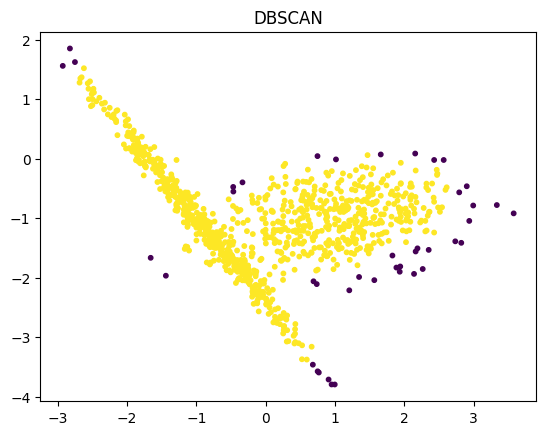

In [9]:
dbscan = DBSCAN(eps=0.25, min_samples=8)
y_pr = dbscan.fit_predict(X1)
plt.scatter(X1[:,0], X1[:,1], s = 10, c = y_pr)
plt.title('DBSCAN')

<h2 style="color: green;">
    Dataset 1 Winner - GMM
</h2>

Text(0.5, 1.0, 'GMM')

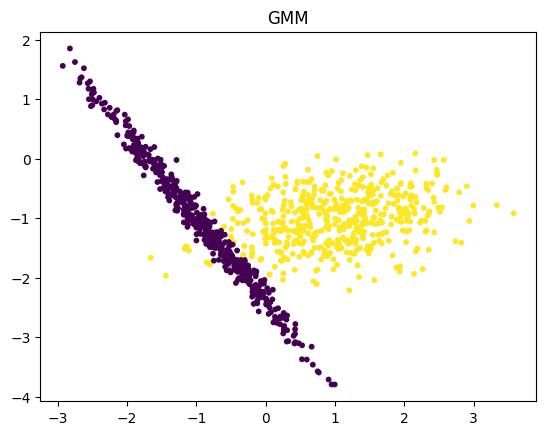

In [10]:
gmm = GaussianMixture(n_components = 2)
y_pr = gmm.fit_predict(X1)
plt.scatter(X1[:,0], X1[:,1], s = 10, c = y_pr)
plt.title('GMM')

# Dataset 2 

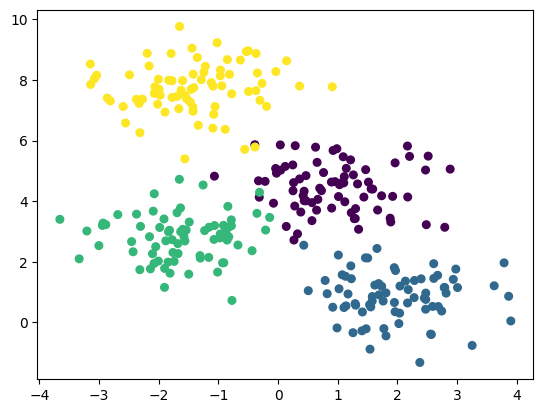

In [11]:
X2, y2 = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=0)
plt.scatter(X2[:, 0], X2[:, 1], s=30, c=y2);

<h2 style="color: green;">
    Dataset 2 Winner - KMeans
</h2>

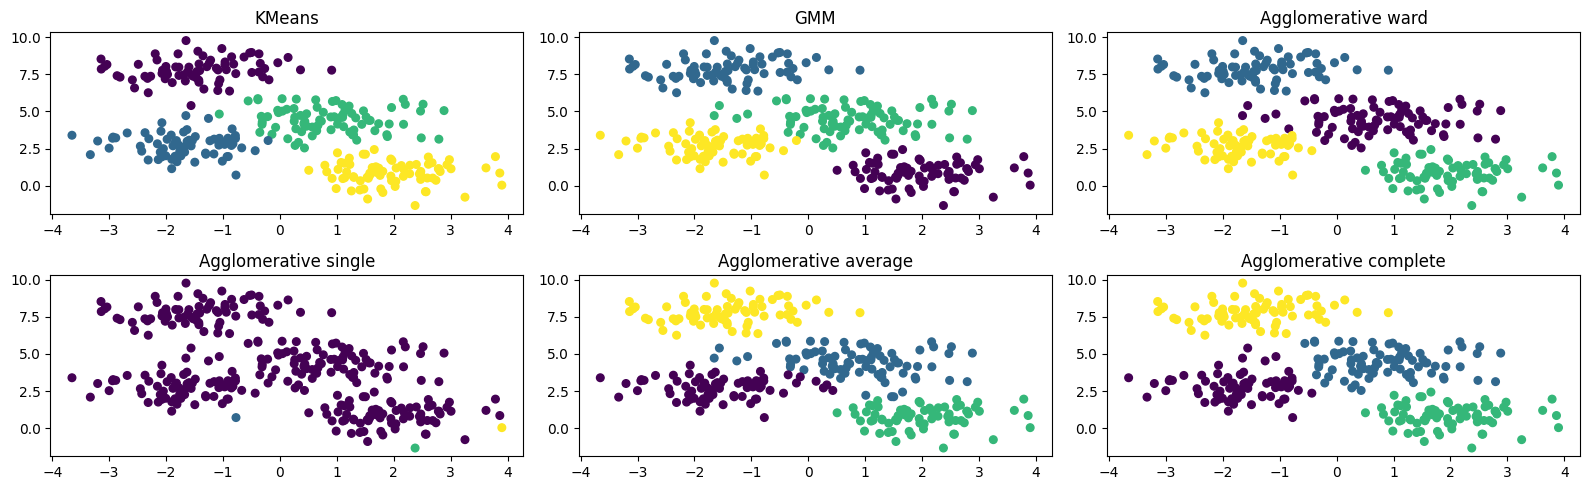

In [12]:
evaluate(X2, 4, 30)

# Dataset 3 

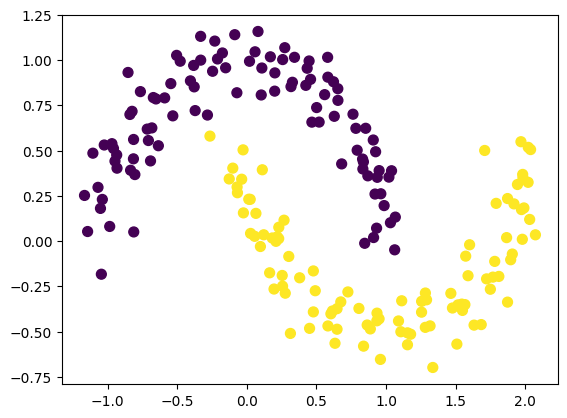

In [13]:
X3, y3 = make_moons(200, noise=0.1, random_state=0)
plt.scatter(X3[:, 0], X3[:, 1], s=50, c=y3);

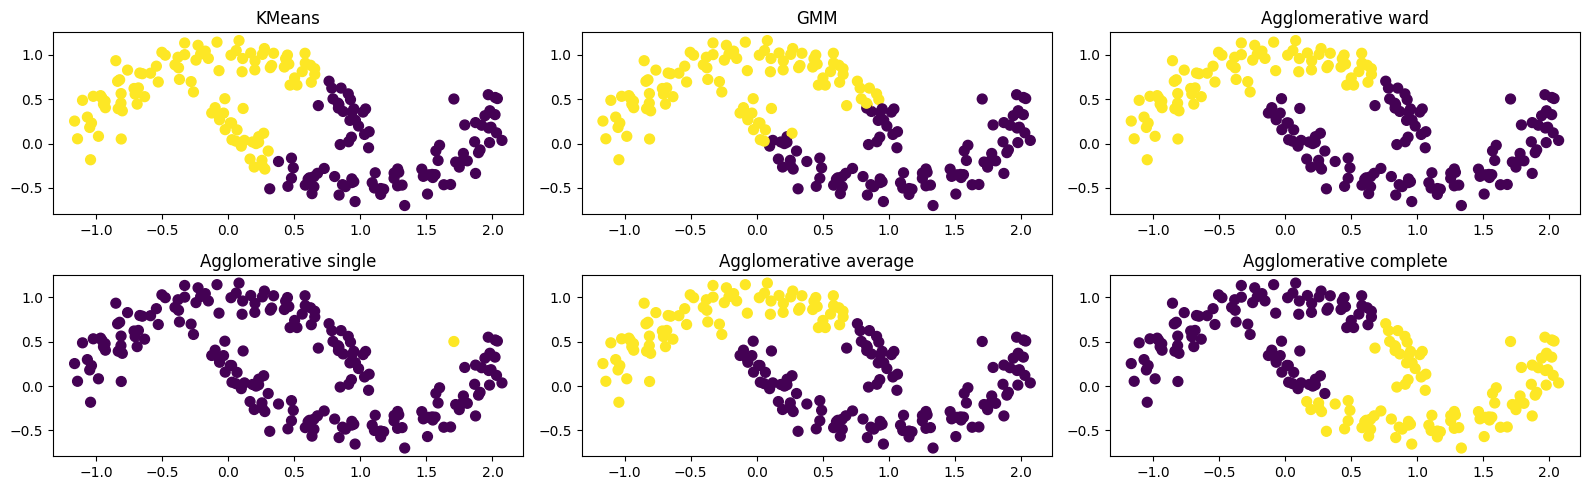

In [14]:
evaluate(X3, 2, 50)

<h2 style="color: green;">
    Dataset 3 Winner - DBSCAN
</h2>

Text(0.5, 1.0, 'DBSCAN')

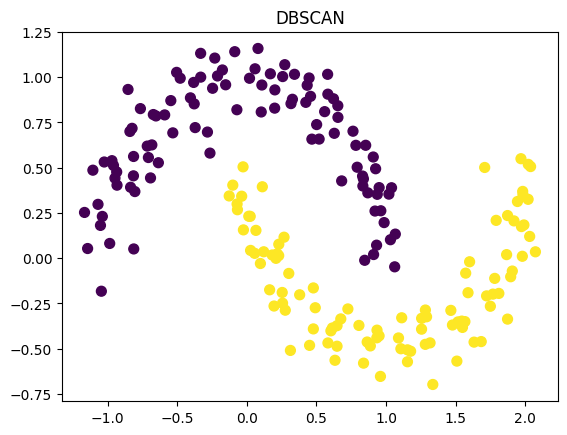

In [15]:
db = DBSCAN(eps=0.27, min_samples=7)
y = db.fit_predict(X3)
plt.scatter(X3[:,0], X3[:,1], c = y, s = 50)
plt.title('DBSCAN')

# Dataset 4

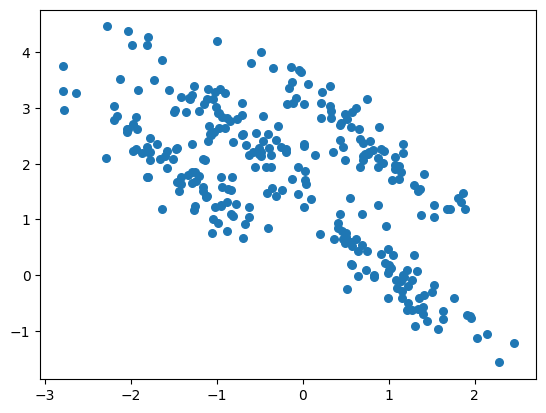

In [16]:
rng = np.random.RandomState(13)
X4 = np.dot(X2, rng.randn(2, 2))

plt.scatter(X4[:, 0], X4[:, 1], s=30);

Text(0.5, 1.0, 'DBSCAN')

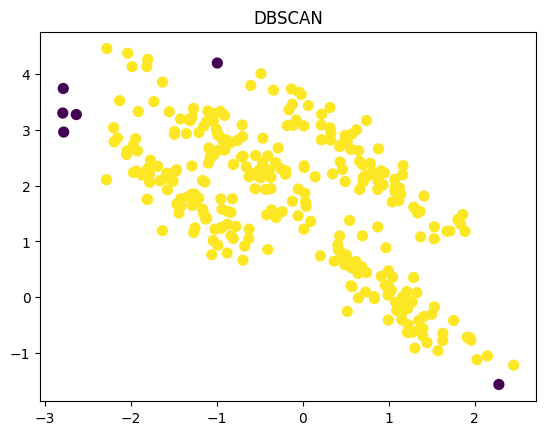

In [17]:
db = DBSCAN(eps=0.45, min_samples=5)
y = db.fit_predict(X4)
plt.scatter(X4[:,0], X4[:,1], c = y, s = 50)
plt.title('DBSCAN')

<h2 style="color: green;">
    Dataset 4 Winner - GMM
</h2>

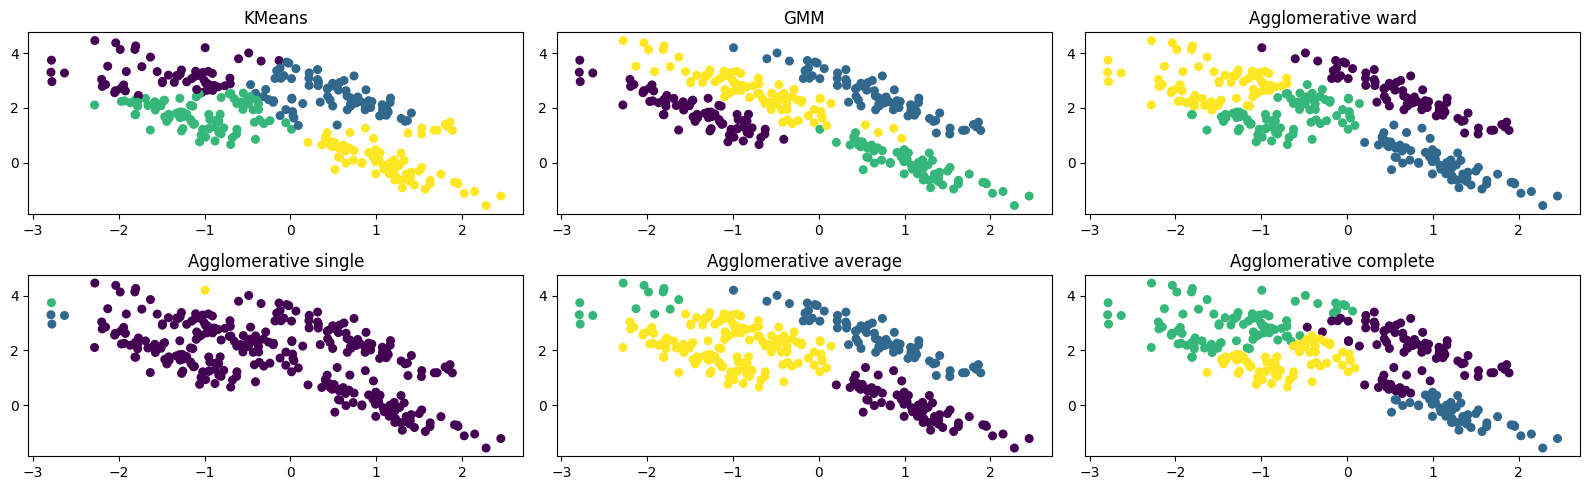

In [18]:
evaluate(X4, 4)

# Dataset 5

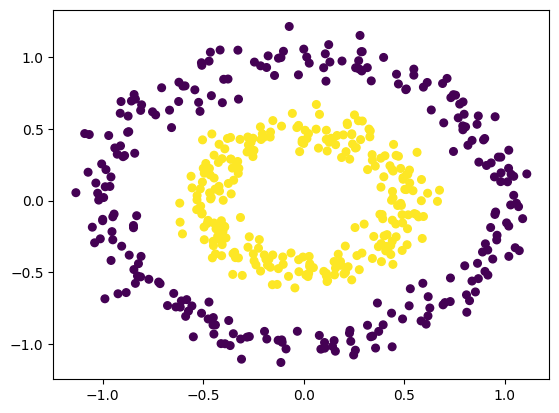

In [19]:
X5, y5 = make_circles(n_samples=500, factor=0.5, noise=0.07, random_state=42)
plt.scatter(X5[:, 0], X5[:, 1], s=30, c=y5);

Text(0.5, 1.0, 'DBSCAN')

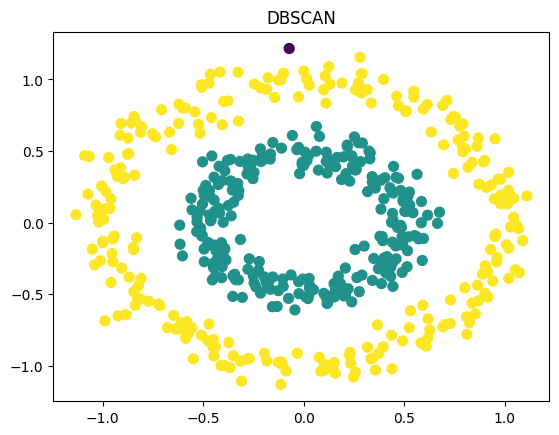

In [20]:
db = DBSCAN(eps=0.168, min_samples=5)
y = db.fit_predict(X5)
plt.scatter(X5[:,0], X5[:,1], c = y, s = 50)
plt.title('DBSCAN')

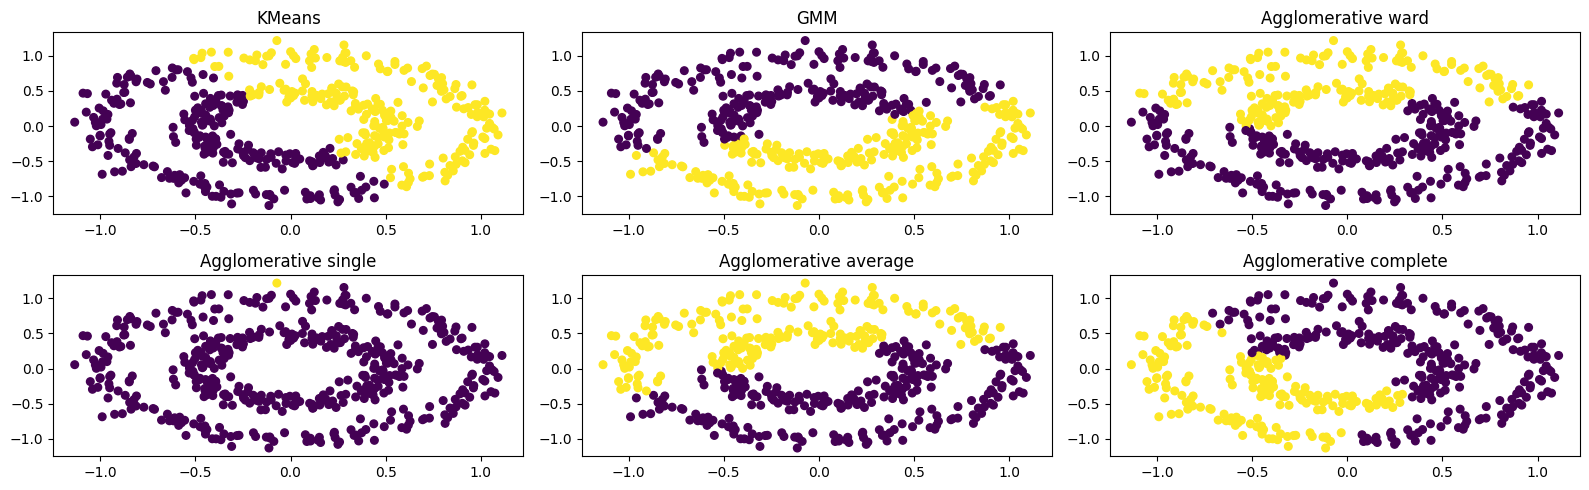

In [21]:
evaluate(X5, 2)

# Dataset 6

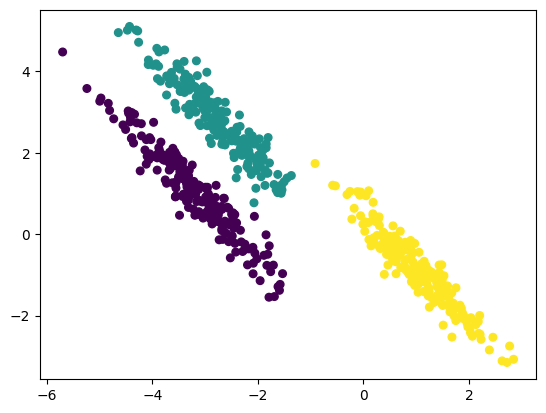

In [22]:
X_blobs, y_blobs = make_blobs(n_samples=600, random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X6 = np.dot(X_blobs, transformation)

y6 = y_blobs
plt.scatter(X6[:, 0], X6[:, 1], s=30, c=y6);

<h2 style="color: green;">
    Dataset 6 Winner - GMM
</h2>

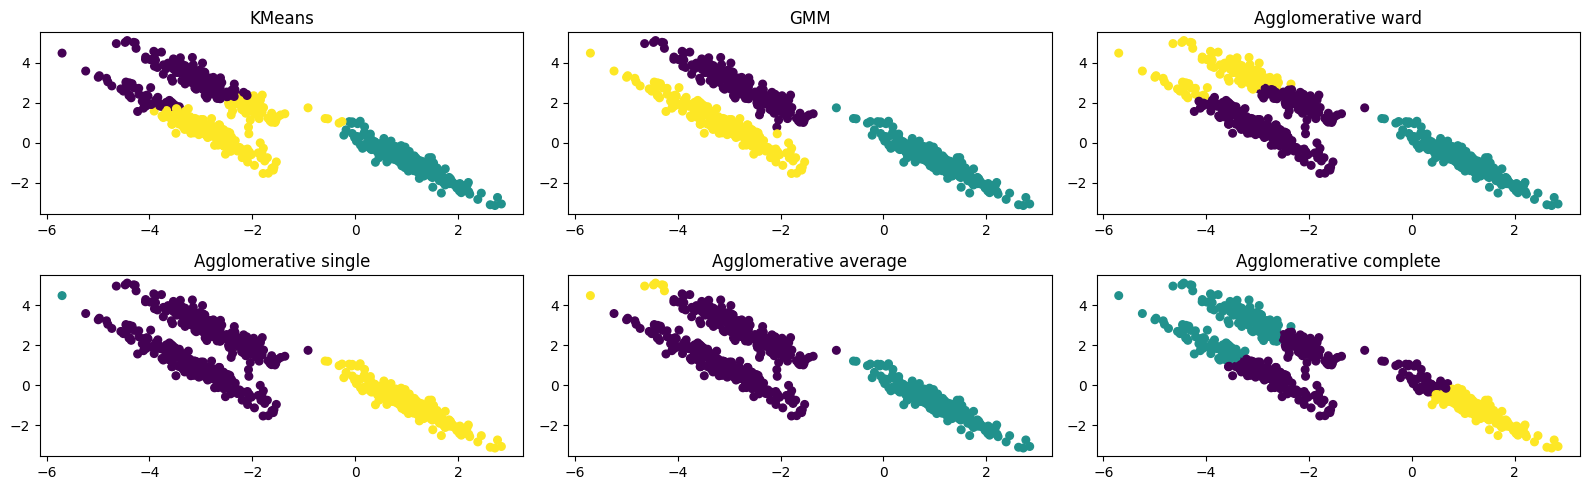

In [23]:
evaluate(X6,3)

Text(0.5, 1.0, 'DBSCAN')

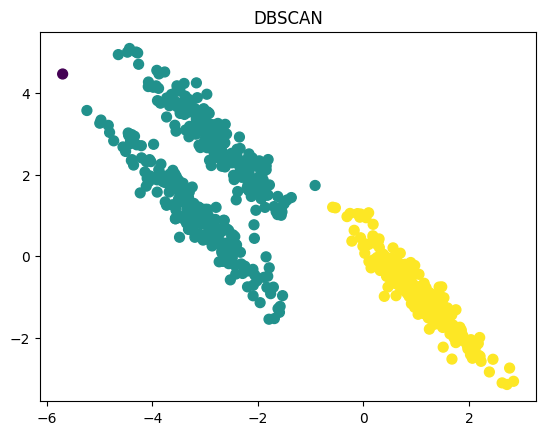

In [24]:
db = DBSCAN(eps=0.7, min_samples=7)
y = db.fit_predict(X6)
plt.scatter(X6[:,0], X6[:,1], c = y, s = 50)
plt.title('DBSCAN')

# Dataset 7

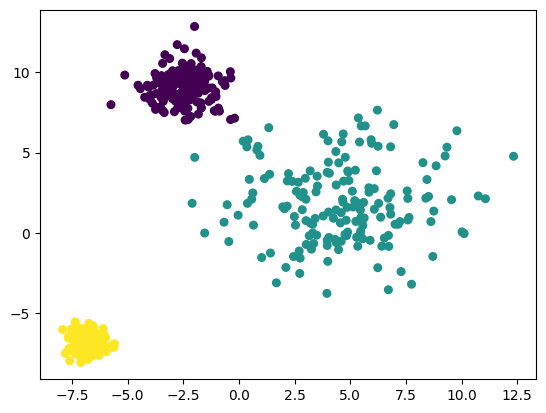

In [25]:
X7, y7 = make_blobs(n_samples=500, cluster_std=[1.0, 2.5, 0.5], random_state=42)
plt.scatter(X7[:, 0], X7[:, 1], s=30, c=y7);

<h2 style="color: green;">
    Dataset 7 Winner - GMM
</h2>

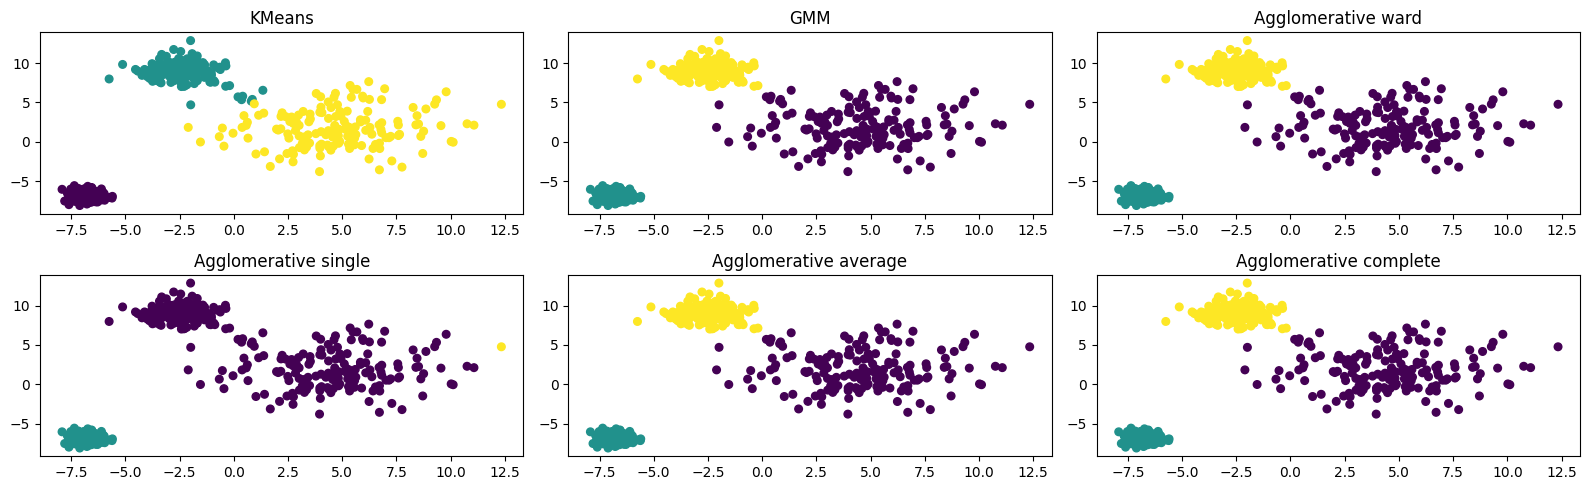

In [26]:
evaluate(X7, 3)

# Dataset 8

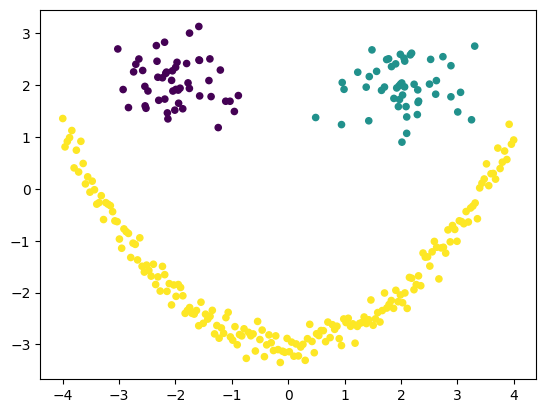

In [27]:
X_eyes, y_eyes = make_blobs(n_samples=100, centers=[[-2, 2], [2, 2]], cluster_std=0.5, random_state=43)
X_smile = np.zeros((200, 2))
X_smile[:, 0] = np.linspace(-4, 4, 200)
X_smile[:, 1] = (X_smile[:, 0]**2) / 4 - 3 + np.random.normal(0, 0.2, 200)
X8 = np.vstack([X_eyes, X_smile])
y8 = np.hstack([y_eyes, np.full(200, 2)])
plt.scatter(X8[:, 0], X8[:, 1], s=20, c=y8);

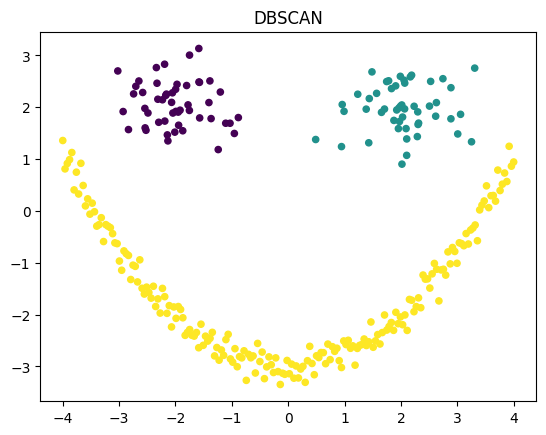

In [28]:
db = DBSCAN(eps = 0.79, min_samples=7)
y = db.fit_predict(X8)
plt.title('DBSCAN')
plt.scatter(X8[:, 0], X8[:, 1], s=20, c=y)

<h2 style="color: green;">
    Dataset 8 Winner - DBSCAN & Agglomerative single
</h2>

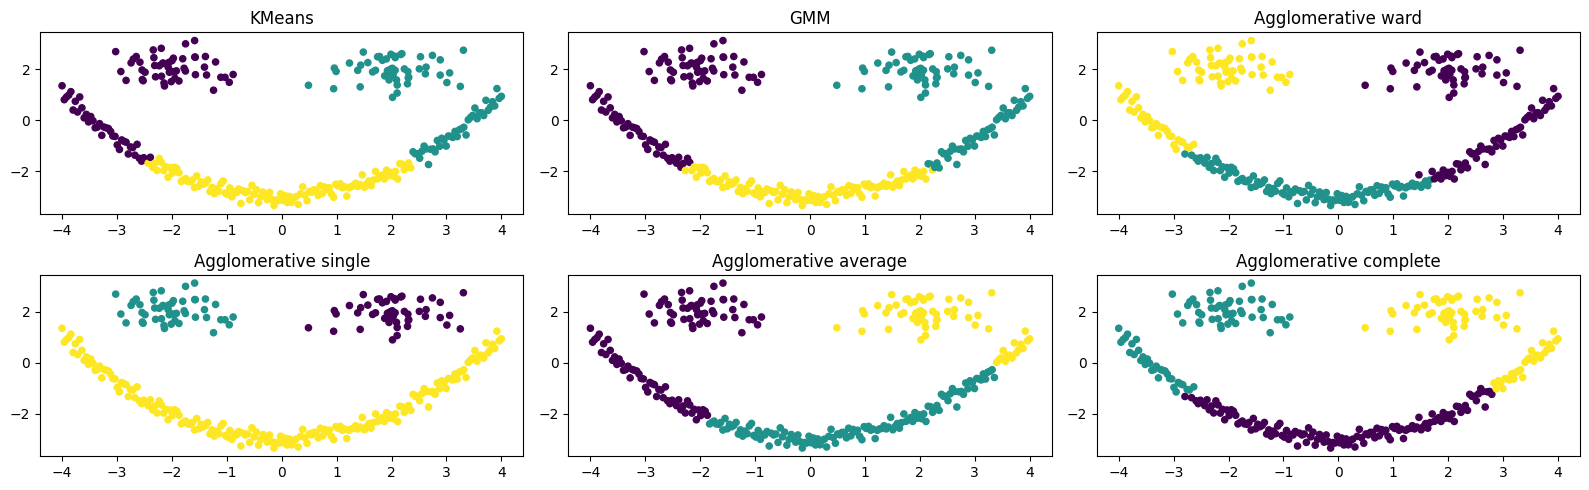

In [29]:
evaluate(X8, 3, 20)

# Dataset 9

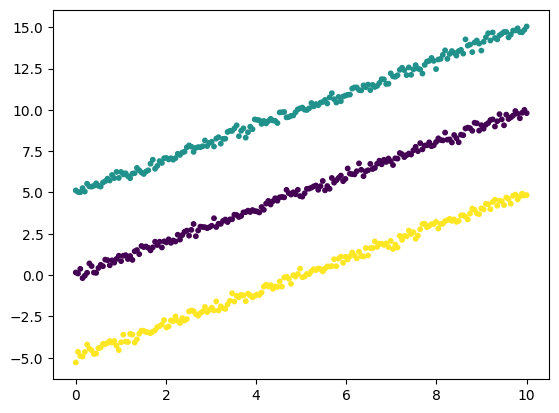

In [30]:
X9 = np.zeros((600, 2))
X9[:200, 0] = np.linspace(0, 10, 200)
X9[:200, 1] = X9[:200, 0] + np.random.normal(0, 0.2, 200)
X9[200:400, 0] = np.linspace(0, 10, 200)
X9[200:400, 1] = X9[200:400, 0] + 5 + np.random.normal(0, 0.2, 200)
X9[400:, 0] = np.linspace(0, 10, 200)
X9[400:, 1] = X9[400:, 0] - 5 + np.random.normal(0, 0.2, 200)
y9 = np.hstack([np.zeros(200), np.ones(200), np.full(200, 2)])
plt.scatter(X9[:, 0], X9[:, 1], s=10, c=y9);

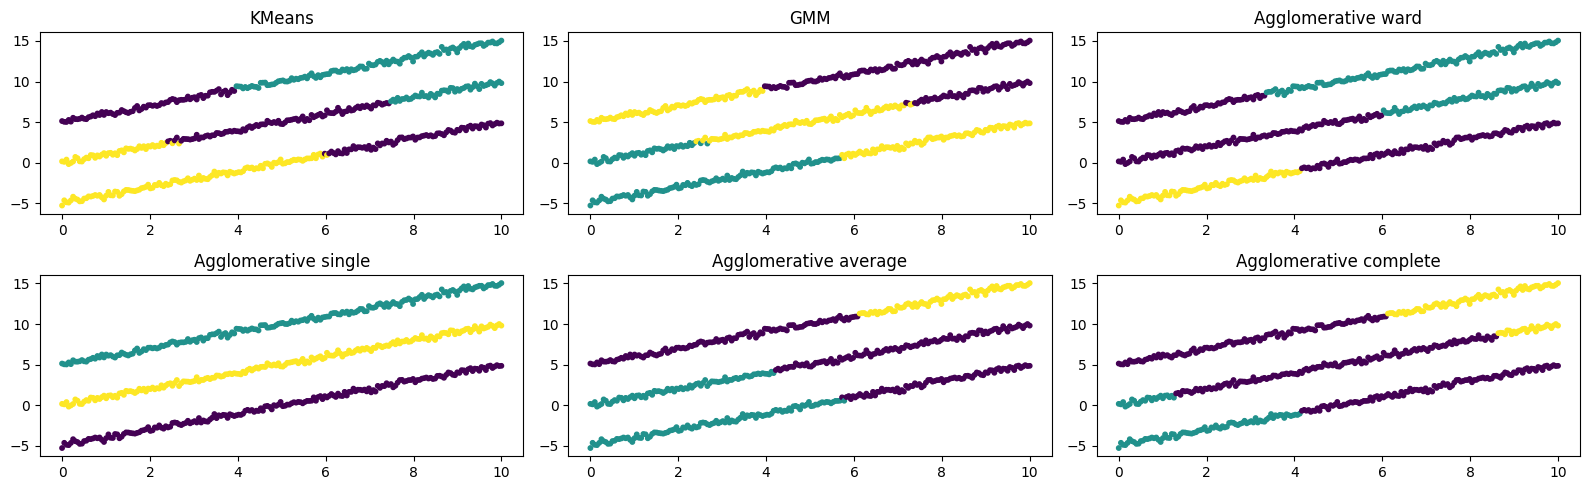

In [31]:
evaluate(X9, 3, 10)

<h2 style="color: green;">
    Dataset 9 Winner - DBSCAN & Agglomerative single
</h2>

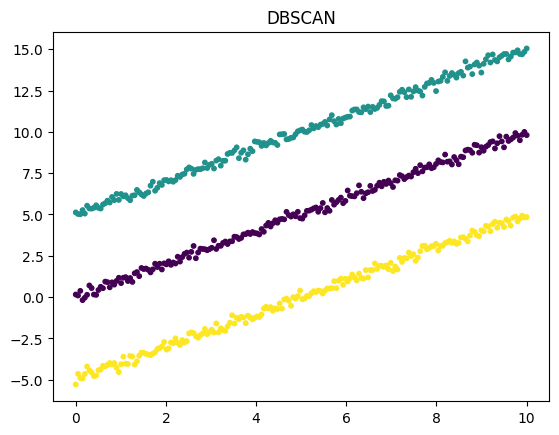

In [32]:
db = DBSCAN(eps = 0.73, min_samples=3)
y = db.fit_predict(X9)
plt.title('DBSCAN')
plt.scatter(X9[:, 0], X9[:, 1], s=10, c=y)

# Dataset 10

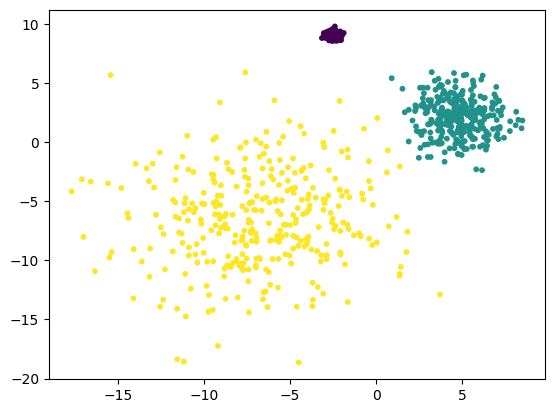

In [33]:
X10, y10 = make_blobs(n_samples=1000, centers=3, cluster_std=[0.2, 1.5, 4.0], random_state=42)
plt.scatter(X10[:, 0], X10[:, 1], s=10, c=y10);

<h2 style="color: green;">
    Dataset 10 Winner - GMM & Agglomerative ward
</h2>

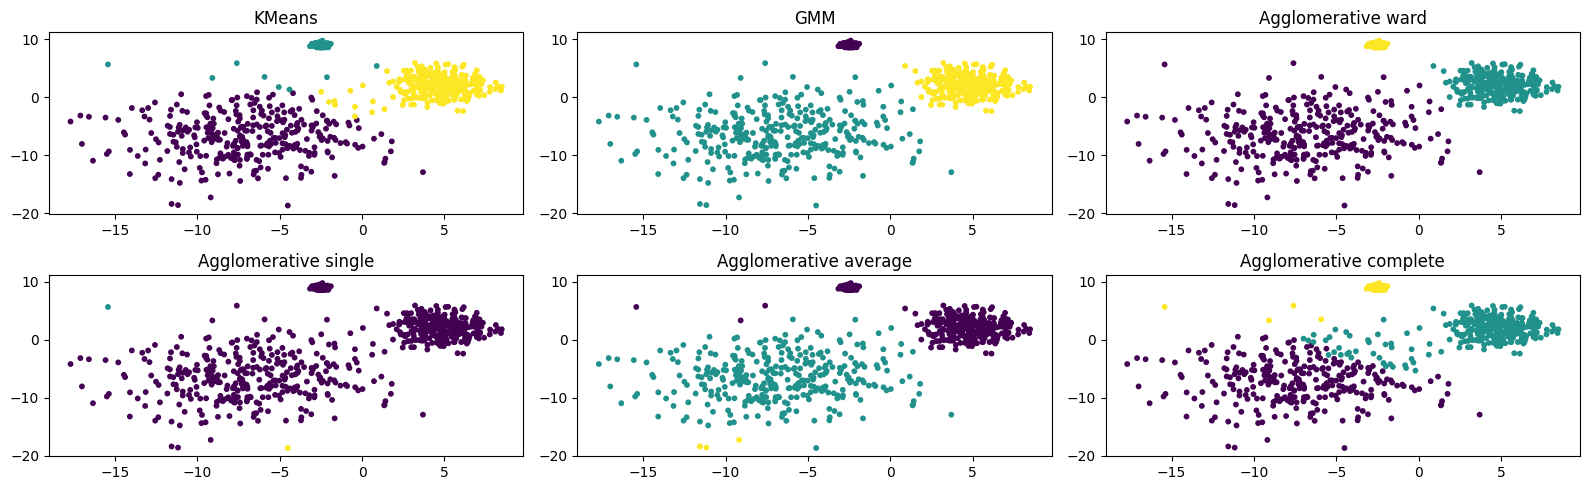

In [34]:
evaluate(X10, 3, 10)

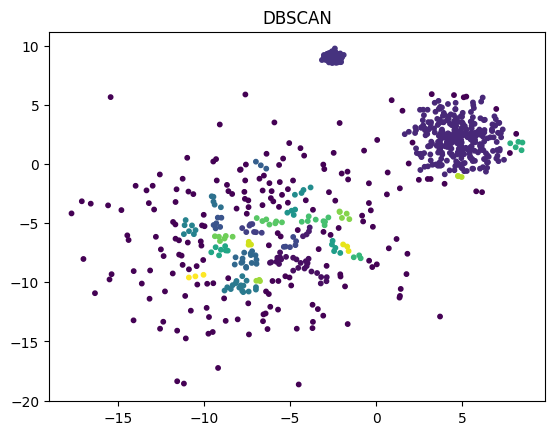

In [35]:
db = DBSCAN(eps = 0.5, min_samples=3)
y = db.fit_predict(X10)
plt.title('DBSCAN')
plt.scatter(X10[:, 0], X10[:, 1], s=10, c=y)